In [50]:
## Machine learning project

In [51]:
import os
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"

import numpy as np
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA

In [52]:
mall = pd.read_csv('mallcustomers.csv')

Problem 1 (Preprocessing) 10%
Preview the dataset and make note of the data types for each variable. You will notice that
the Income variable is stored as a string. Since k-means needs numeric data in order to
calculate the Euclidean distance between points, you’ll need to convert Income to a
numeric value. To do so, you’ll first need to remove the substrings “,” and “USD” from the
data. Make this change

In [54]:
mall.head()

,CustomerID,Gender,Age,Income,SpendingScore
0,1,Male,19,"15,000 USD",39
1,2,Male,21,"15,000 USD",81
2,3,Female,20,"16,000 USD",6
3,4,Female,23,"16,000 USD",77
4,5,Female,31,"17,000 USD",40


In [55]:
mall.info()     

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   CustomerID     200 non-null    int64 
 1   Gender         200 non-null    object
 2   Age            200 non-null    int64 
 3   Income         200 non-null    object
 4   SpendingScore  200 non-null    int64 
dtypes: int64(3), object(2)
memory usage: 7.9+ KB


In [56]:
mall["Income"] = (mall["Income"].astype(str)
    .str.replace(",", "")
    .str.replace("USD", ""))

In [57]:
mall["Income"] = (mall["Income"].astype(int))

Problem 2 (Preprocessing) 10%
Since our model will be using only Income and SpendingScore, you’ll need to exclude the
other features that aren’t useful for segmentation. Eliminate CustomerID

In [59]:
mall_incomespending = mall.drop(columns=["CustomerID", "Gender", "Age"])

mall_incomespending.head()

,Income,SpendingScore
0,15000,39
1,15000,81
2,16000,6
3,16000,77
4,17000,40


Problem 3 (Preprocessing) 10%
Run some summary statistics for Income and SpendingScore. The summary statistics
show that there appears to be a significant difference in the scale of the Income and
SpendingScore features. Use what you have learned to normalize this data using the z-
score normalization approach

In [61]:
summary_stats = mall_incomespending.describe()
print(summary_stats)

              Income  SpendingScore
count     200.000000     200.000000
mean    60560.000000      50.200000
std     26264.721165      25.823522
min     15000.000000       1.000000
25%     41500.000000      34.750000
50%     61500.000000      50.000000
75%     78000.000000      73.000000
max    137000.000000      99.000000


In [62]:
cols = ['Income', 'SpendingScore']
scaler = StandardScaler()

mall_incomespending[cols] = scaler.fit_transform(mall_incomespending[cols])

Problem 4 (Data Clustering) 30%
Now that you have normalized the data, apply k-means to cluster the data. In order to
determine how many clusters to create, use the Elbow Method to determine an optimal
number of clusters. Now that you have determined your k value, create the final set of
clusters and visualize the results. Remember to set your random seed to 42 so that your
results can be replicated

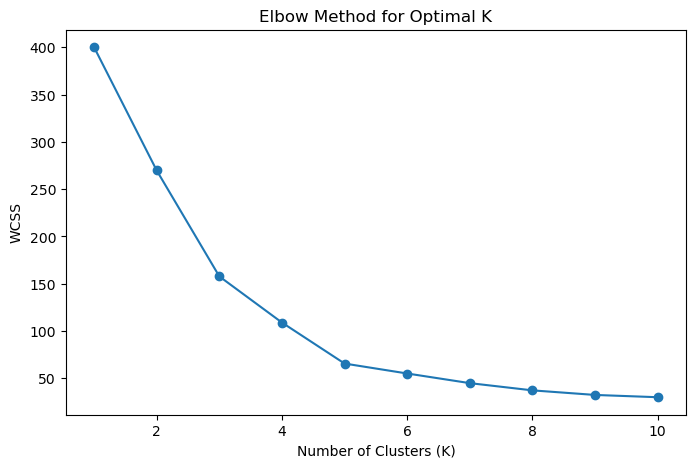

In [64]:
# Compute WCSS for different K values
wcss = []
K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(mall_incomespending)
    wcss.append(kmeans.inertia_)  # Sum of squared distances

# Plot the Elbow Method   
plt.figure(figsize=(8, 5))
plt.plot(K_range, wcss, marker='o', linestyle='-')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS')
plt.title('Elbow Method for Optimal K')
plt.show()

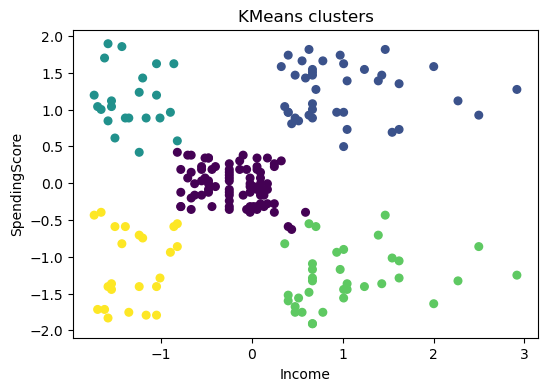

In [65]:
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)   # k = 5  # based on elbow method
kmeans.fit(mall_incomespending)

labels = kmeans.labels_

plt.figure(figsize=(6, 4))
plt.scatter(mall_incomespending['Income'], mall_incomespending['SpendingScore'],
    c=labels, cmap='viridis', s=30)
plt.xlabel('Income')
plt.ylabel('SpendingScore')
plt.title(f'KMeans clusters')   
plt.show()

Problem 5 (Evaluating the Clusters) 40% Now that you have visualized the clusters, give names to each cluster based upon their respective locations on the visualization. Having seen your results, mall management now wants some additional demographic information about each cluster. Use the features Gender and Age to determine the gender distribution and mean age for each cluster. HINT: You’ll need to create two dummy variables—Male and Female—to represent the Gender feature. What does this additional information tell you about each cluster?

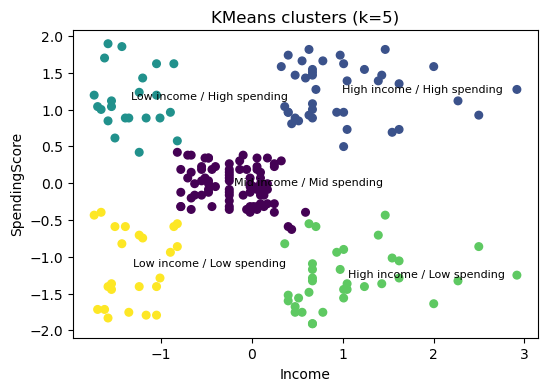

In [67]:
# Give names to each cluster based upon their respective locations on the visualization. 
cols = ["Income", "SpendingScore"]
kmeans_final = KMeans(n_clusters=5, random_state=42, n_init=10)
kmeans_final.fit(mall_incomespending[cols])          # fit the model

# Find the cluster centers for cluster names
centers = kmeans_final.cluster_centers_

# Name & plot the clusters
cluster_names = {0: "Mid income / Mid spending",
                 1: "High income / High spending",
                 2: "Low income / High spending",
                 3: "High income / Low spending",
                 4: "Low income / Low spending"}

mall_incomespending = mall_incomespending.copy()
mall_incomespending["Cluster"] = kmeans_final.labels_
mall_incomespending["ClusterName"] = mall_incomespending["Cluster"].map(cluster_names)

plt.figure(figsize=(6, 4))
plt.scatter(mall_incomespending["Income"],
            mall_incomespending["SpendingScore"],
            c=mall_incomespending["Cluster"],
            cmap="viridis",
            s=30)
plt.xlabel("Income")
plt.ylabel("SpendingScore")
plt.title(f"KMeans clusters (k=5)")

centers = kmeans.cluster_centers_
for i, (cx, cy) in enumerate(centers):
    plt.text(cx, cy, cluster_names.get(i, str(i)), fontsize=8)

plt.show()

In [68]:
# Having seen your results, mall management now wants some additional demographic information about each cluster. 
# Use the features Gender and Age to determine the gender distribution and mean age for each cluster. 
# HINT: You’ll need to create two dummy variables—Male and Female—to represent the Gender feature. 

In [69]:
mall_agegender = mall[["Age", "Gender"]]
gender_dummies = pd.get_dummies(mall_agegender["Gender"])

print(gender_dummies)

     Female   Male
0     False   True
1     False   True
2      True  False
3      True  False
4      True  False
..      ...    ...
195    True  False
196    True  False
197   False   True
198   False   True
199   False   True

[200 rows x 2 columns]


In [70]:
mall_agegender = pd.concat([mall_agegender, gender_dummies], axis=1)

print(mall_agegender)

     Age  Gender  Female   Male
0     19    Male   False   True
1     21    Male   False   True
2     20  Female    True  False
3     23  Female    True  False
4     31  Female    True  False
..   ...     ...     ...    ...
195   35  Female    True  False
196   45  Female    True  False
197   32    Male   False   True
198   32    Male   False   True
199   30    Male   False   True

[200 rows x 4 columns]


In [71]:
# Show the cluster number for each row
mall_agegender["cluster"] = kmeans_final.labels_
print(mall_agegender)

     Age  Gender  Female   Male  cluster
0     19    Male   False   True        4
1     21    Male   False   True        2
2     20  Female    True  False        4
3     23  Female    True  False        2
4     31  Female    True  False        4
..   ...     ...     ...    ...      ...
195   35  Female    True  False        1
196   45  Female    True  False        3
197   32    Male   False   True        1
198   32    Male   False   True        3
199   30    Male   False   True        1

[200 rows x 5 columns]


In [72]:
# group by cluster
mall_agegender_copy = mall_agegender.copy()

gender_dist = mall_agegender_copy.groupby("cluster")[["Male", "Female"]].sum()
mean_age = mall_agegender_copy.groupby("cluster")["Age"].mean()

agegender_clusters = pd.concat(
    [gender_dist, mean_age.rename("Mean_Age")],
    axis=1)

print(agegender_clusters)

         Male  Female   Mean_Age
cluster                         
0          33      48  42.716049
1          18      21  32.692308
2           9      13  25.272727
3          19      16  41.114286
4           9      14  45.217391


In [73]:
# combined cluster info:
income_spending_clusters = (mall_incomespending
    .groupby("Cluster")[["ClusterName", "Income", "SpendingScore"]]
    .first())

final_cluster_summary = agegender_clusters.join(
    income_spending_clusters.rename(columns={"ClusterName": "cluster_name"}))

final_cluster_summary.head(5)

,Male,Female,Mean_Age,cluster_name,Income,SpendingScore
cluster,,,,,,
0,33,48,42.716049,Mid income / Mid spending,-0.822933,0.419273
1,18,21,32.692308,High income / High spending,0.322150,1.583920
2,9,13,25.272727,Low income / High spending,-1.738999,1.195704
3,19,16,41.114286,High income / Low spending,0.360319,-0.823017
4,9,14,45.217391,Low income / Low spending,-1.738999,-0.434801


# Summary for Mall Management:

The 200 shoppers from “mallcustomers” information has shown a few things about customer spending.  
Mean spending is 60,560 USD with minimum spending being 15,000 USD and max spending 137,000 USD.  (USD = U.S. Dollars)  
Based on the income and spending score provided by your data, 
there are 5 main groups of spending patterns among these customers that have been identified as:
•	Low income / Low spending
•	Mid income / Mid spending
•	High income / High spending
•	Low income / High spending
•	High income / Low spending

More females than males are spending in these categories with one exception.  
The High income / Low spending group is mostly male with a mean age of 41.  Average ages for the other 4 groups are as follows:
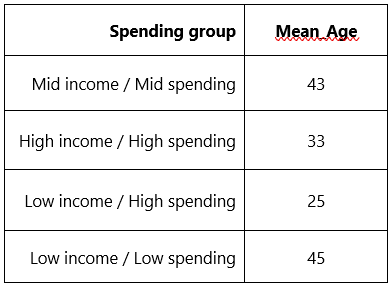

This may provide some valuable information for advertising, promotions and may help explain some sales figures.